# 05 · Backtesting — Quick Test & Validation
**Script chính:** `scripts/run_backtest.py`  
**Notebook này:** Load equity curves + metrics → kiểm tra returns, Sharpe, drawdown, so sánh vs benchmark.

In [1]:
import sys, warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.config import load_config
from src.backtest import compute_metrics
from src.utils.io import load

cfg = load_config(ROOT / 'configs' / 'base.yaml')

## 1. Load All Equity Curves

In [2]:
out = cfg.dir_outputs
equities = {}
equity_files = {
    'ML_Full_EW': 'equity_full.parquet',
    'ML_Full_CW': 'equity_cw.parquet',
    'BH_QQQ': 'equity_benchmark_qqq.parquet',
    'BH_MCap10': 'equity_benchmark_mcap10.parquet',
    'BH_Full': 'equity_benchmark_full.parquet',
}

for name, fname in equity_files.items():
    path = out / fname
    if path.exists():
        equities[name] = load(path)
        print(f"  {name}: {len(equities[name]):,} days, "
              f"final=${equities[name]['equity'].iloc[-1]:,.0f}")
    else:
        print(f"  {name}: NOT FOUND")

assert len(equities) >= 3, f'Too few equity curves loaded: {len(equities)}'
print(f'\nLoaded {len(equities)} equity curves')

  ML_Full_EW: 1,536 days, final=$54,358
  ML_Full_CW: 1,536 days, final=$60,073
  BH_QQQ: 1,536 days, final=$28,174
  BH_MCap10: 1,536 days, final=$57,820
  BH_Full: 1,536 days, final=$30,424

Loaded 5 equity curves


## 1b. Data Inspection — nhìn thẳng vào equity curves

In `head/tail/describe` của 1 equity curve mẫu (ML_Full_CW) + bảng tóm tắt first/last/min/max của tất cả strategies để xác nhận shape, range, daily return distribution.

In [3]:
sample_name = 'ML_Full_CW'
sample_eq = equities[sample_name]

print(f"--- {sample_name}: columns + dtypes ---")
print(sample_eq.dtypes.to_string())
print(f"\n--- {sample_name} HEAD(10) ---")
print(sample_eq.head(10).round(6).to_string())

print(f"\n--- {sample_name} TAIL(5) ---")
print(sample_eq.tail(5).round(6).to_string())

print(f"\n--- {sample_name} describe() ---")
print(sample_eq.describe().round(6).to_string())

print("\n--- All strategies: equity summary ---")
summary = pd.DataFrame({
    n: {
        'first_date': eq.index.min(),
        'last_date': eq.index.max(),
        'n_days': len(eq),
        'equity_first': eq['equity'].iloc[0],
        'equity_last': eq['equity'].iloc[-1],
        'equity_min': eq['equity'].min(),
        'equity_max': eq['equity'].max(),
        'mean_daily_ret': eq['daily_ret'].mean(),
        'std_daily_ret': eq['daily_ret'].std(),
    }
    for n, eq in equities.items()
}).T
print(summary.to_string())

print("\n--- All strategies: daily return distribution (quantiles) ---")
ret_quantiles = pd.DataFrame({
    n: eq['daily_ret'].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    for n, eq in equities.items()
})
print(ret_quantiles.round(5).to_string())

--- ML_Full_CW: columns + dtypes ---
equity                         float64
daily_ret                      float64
gross_ret                      float64
cost_ret                       float64
is_entry_day                      bool
rebalance_date          datetime64[us]
signal_date             datetime64[us]
exposure                       float64
regime_scale                   float64
defense_scale                  float64
vol_scale                      float64
dd_scale                       float64
estimated_vol                   object
regime_score                    object
breadth_gate                      bool
benchmark_trend_gate              bool
anchor_used                       bool

--- ML_Full_CW HEAD(10) ---
                  equity  daily_ret  gross_ret  cost_ret  is_entry_day rebalance_date signal_date  exposure  regime_scale  defense_scale  vol_scale  dd_scale estimated_vol regime_score  breadth_gate  benchmark_trend_gate  anchor_used
date                                 

## 2. Metrics Comparison Table

In [4]:
all_metrics = {name: compute_metrics(eq) for name, eq in equities.items()}
metrics_df = pd.DataFrame(all_metrics).T

display_cols = ['CAGR', 'Sharpe', 'Max_Drawdown', 'Calmar', 'Sortino', 'Win_Rate']
display_cols = [c for c in display_cols if c in metrics_df.columns]
print(metrics_df[display_cols].round(3).to_string())

# Cross-check vs script-exported metrics
script_metrics_path = cfg.dir_outputs / 'metrics' / 'backtest_metrics.csv'
if script_metrics_path.exists():
    script_m = pd.read_csv(script_metrics_path, index_col=0)
    common = set(metrics_df.index) & set(script_m.index)
    if common and 'CAGR' in script_m.columns:
        for strat in common:
            nb_cagr = metrics_df.loc[strat, 'CAGR']
            sc_cagr = script_m.loc[strat, 'CAGR']
            diff = abs(nb_cagr - sc_cagr)
            assert diff < 0.01, f"{strat} CAGR mismatch: nb={nb_cagr:.3f} vs script={sc_cagr:.3f}"
        print(f"\nOK: Metrics match script output ({len(common)} strategies checked)")
else:
    print("\nSKIP: backtest_metrics.csv not found")

             CAGR  Sharpe  Max_Drawdown  Calmar  Sortino  Win_Rate
ML_Full_EW  0.319   0.877        -0.371   0.859    1.226     0.533
ML_Full_CW  0.341   0.910        -0.376   0.906    1.262     0.538
BH_QQQ      0.185   0.645        -0.351   0.526    0.848     0.559
BH_MCap10   0.332   0.852        -0.574   0.579    1.202     0.546
BH_Full     0.200   0.697        -0.324   0.617    0.925     0.561

OK: Metrics match script output (5 strategies checked)


## 3. Equity Curves & Drawdown

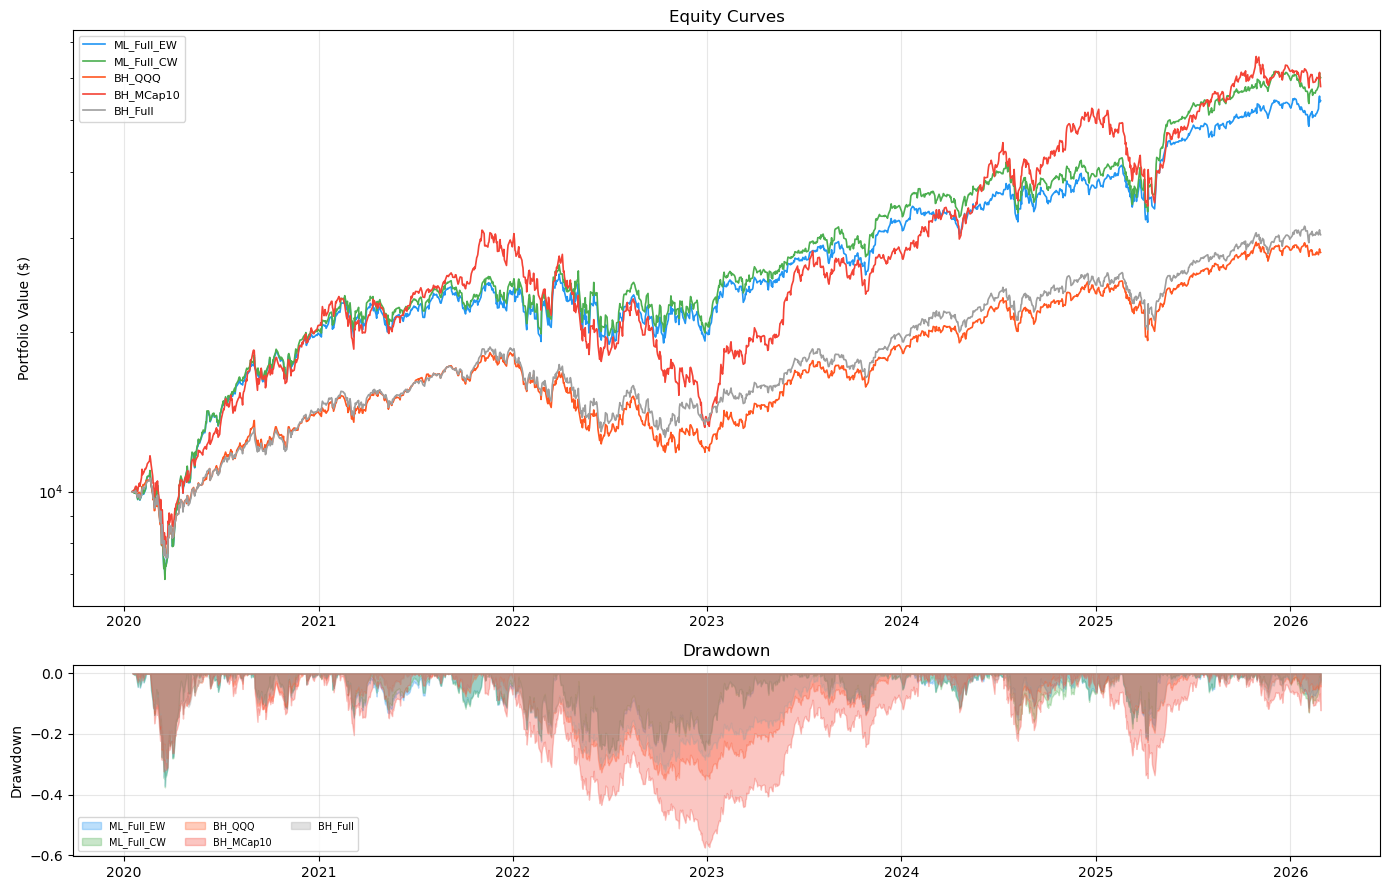

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={'height_ratios': [3, 1]})

colors = {'ML_Full_EW': '#2196F3', 'ML_Full_CW': '#4CAF50',
          'BH_QQQ': '#FF5722',
          'BH_MCap10': '#F44336', 'BH_Full': '#9E9E9E'}

# Equity curves
for name, eq in equities.items():
    c = colors.get(name, None)
    axes[0].plot(eq.index, eq['equity'], label=name, linewidth=1.2, color=c)
axes[0].set_title('Equity Curves')
axes[0].set_ylabel('Portfolio Value ($)')
axes[0].legend(fontsize=8)
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# Drawdown
for name, eq in equities.items():
    dd = eq['equity'] / eq['equity'].cummax() - 1
    c = colors.get(name, None)
    axes[1].fill_between(dd.index, dd, 0, alpha=0.3, label=name, color=c)
axes[1].set_title('Drawdown')
axes[1].set_ylabel('Drawdown')
axes[1].legend(fontsize=7, ncol=3)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Random Benchmark Check

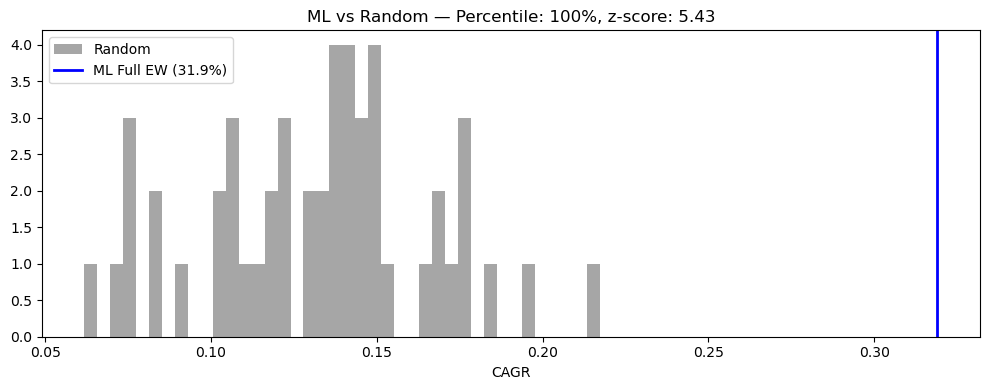

Random: 50 iterations
  CAGR: 13.2% +/- 3.4%
  ML at percentile 100%, z=5.43
OK: ML outperforms random mean


In [6]:
rand_path = cfg.dir_outputs / 'metrics' / 'random_benchmark_stats.csv'
if rand_path.exists():
    rand_df = pd.read_csv(rand_path)
    rand_cagr = rand_df['CAGR']
    ml_cagr = all_metrics.get('ML_Full_EW', {}).get('CAGR', 0)
    
    percentile = (rand_cagr < ml_cagr).mean() * 100
    z = (ml_cagr - rand_cagr.mean()) / max(rand_cagr.std(), 1e-10)
    
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(rand_cagr, bins=40, color='gray', edgecolor='none', alpha=0.7, label='Random')
    ax.axvline(ml_cagr, color='blue', linewidth=2, label=f'ML Full EW ({ml_cagr:.1%})')
    ax.set_title(f'ML vs Random — Percentile: {percentile:.0f}%, z-score: {z:.2f}')
    ax.set_xlabel('CAGR')
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    print(f"Random: {len(rand_df)} iterations")
    print(f"  CAGR: {rand_cagr.mean():.1%} +/- {rand_cagr.std():.1%}")
    print(f"  ML at percentile {percentile:.0f}%, z={z:.2f}")
    assert ml_cagr > rand_cagr.mean(), "ML CAGR below random mean!"
    print("OK: ML outperforms random mean")
else:
    print("SKIP: random_benchmark_stats.csv not found")

## 5. Alpha Testing & Trade Log Check

In [7]:
# Alpha stats
alpha_path = cfg.dir_outputs / 'metrics' / 'alpha_stats.csv'
if alpha_path.exists():
    alpha_df = pd.read_csv(alpha_path)
    print("Alpha Testing (vs QQQ):")
    for _, row in alpha_df.iterrows():
        print(f"  {row['strategy']}: HAC t={row.get('t_stat_alpha', 0):.3f}, "
              f"p={row.get('p_value_alpha', 1):.4f}, "
              f"alpha={row.get('Avg_Annual_Alpha', 0)*100:.2f}%/yr")
else:
    print("SKIP: alpha_stats.csv not found")

# Trade summary
trade_path = cfg.dir_outputs / 'metrics' / 'trade_summary.csv'
if trade_path.exists():
    trade_sum = pd.read_csv(trade_path, index_col=0)
    print(f"\nTrade Summary:")
    print(trade_sum.round(3).to_string())
else:
    print("SKIP: trade_summary.csv not found")

Alpha Testing (vs QQQ):
  ML_Full_EW: HAC t=1.877, p=0.0606, alpha=13.27%/yr
  ML_Full_CW: HAC t=2.062, p=0.0392, alpha=15.22%/yr

Trade Summary:
            N_Rebalances  Avg_Holdings  Avg_N_Sold  Avg_N_Bought  Avg_Turnover_Est  Avg_Cost_Per_Rebalance  Pct_Full_Refresh
ML_Full_EW         148.0          10.0       3.284         3.351             0.406                   0.000               0.0
ML_Full_CW         148.0          10.0       3.284         3.351             0.464                   0.001               0.0


In [8]:
print("=" * 50)
print("05_backtesting: ALL CHECKS PASSED")
print(f"  Strategies loaded: {len(equities)}")
for name in equities:
    m = all_metrics[name]
    print(f"    {name}: CAGR={m['CAGR']:.1%}, Sharpe={m['Sharpe']:.2f}, MDD={m['Max_Drawdown']:.1%}")
print("=" * 50)

05_backtesting: ALL CHECKS PASSED
  Strategies loaded: 5
    ML_Full_EW: CAGR=31.9%, Sharpe=0.88, MDD=-37.1%
    ML_Full_CW: CAGR=34.1%, Sharpe=0.91, MDD=-37.6%
    BH_QQQ: CAGR=18.5%, Sharpe=0.65, MDD=-35.1%
    BH_MCap10: CAGR=33.2%, Sharpe=0.85, MDD=-57.4%
    BH_Full: CAGR=20.0%, Sharpe=0.70, MDD=-32.4%
